# Preference Scores Analysis
This notebook analyzes the pairwise ad preference evaluation results.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/evaluation/preference_scores.csv')
# ../data/evaluation/cross_category_preference_scores.csv
# ../data/evaluation/preference_scores.csv

# Drop the single query that does not have exactly 1,998 pairs to ensure perfectly equal weighting
query_counts = df['query'].value_counts()
# valid_queries = query_counts[query_counts == 1998].index
# df = df[df['query'].isin(valid_queries)]

display(df.head())
print(f"Total evaluated pairs: {len(df)}")
print(len(query_counts))


,query_id,query,ad_1_id,ad_2_id,winner_ad_id,confidence,is_swapped
0,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Computers & Electronics / Networking::16,Computers & Electronics / nan::1,Computers & Electronics / nan::1,low,False
1,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Computers & Electronics / nan::1,Computers & Electronics / Networking::16,Computers & Electronics / nan::1,low,True
2,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Computers & Electronics / Networking::16,Computers & Electronics / nan::2,Computers & Electronics / nan::2,low,False
3,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Computers & Electronics / nan::2,Computers & Electronics / Networking::16,Computers & Electronics / nan::2,low,True
4,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Computers & Electronics / Networking::16,Computers & Electronics / nan::3,Computers & Electronics / nan::3,low,False


Total evaluated pairs: 2019328
1010


## Confidence Distribution

confidence
low       138086
high       38473
medium     15249
Name: count, dtype: int64

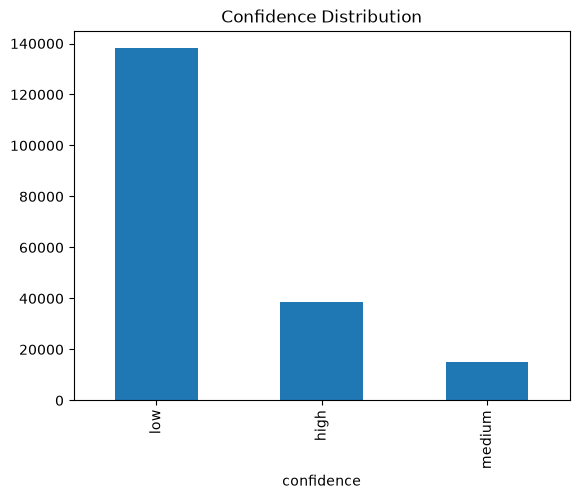

In [3]:
confidence_counts = df['confidence'].value_counts(dropna=False)
display(confidence_counts)
confidence_counts.plot(kind='bar', title='Confidence Distribution')
plt.show()


## Positional Bias Analysis
Let's see if the LLM prefers Ad 1 over Ad 2 simply because it appears first in the prompt.

In [4]:
# win_ad_1 means it chose ad_1.
df['chose_ad_1'] = (df['winner_ad_id'] == df['ad_1_id'])
df['chose_ad_2'] = (df['winner_ad_id'] == df['ad_2_id'])

print("Win rates by position (ad_1 vs ad_2 in prompt):")
print(df[['chose_ad_1', 'chose_ad_2']].mean())


Win rates by position (ad_1 vs ad_2 in prompt):
chose_ad_1    0.483447
chose_ad_2    0.516553
dtype: float64


### Positional Bias Insight
Based on the evaluation data, there is a very slight bias towards the second advertisement in the prompt, but overall it is remarkably balanced:
* **Ad 1 (First Position) Win Rate**: 48.34%
* **Ad 2 (Second Position) Win Rate**: 51.65%

LLMs often exhibit a "recency bias" (favoring the last option presented). In this case, there's a minor ~3.3% recency bias where Llama slightly prefers whichever ad is placed in the `Ad 2` slot. 

By testing every pair bidirectionally (swapping positions) and averaging the results, we successfully cancel out this bias!

## Selected Ad Win Ratio
We define the 'selected ad' as the one initially chosen by the pipeline (which is `ad_1` when `is_swapped=False`, and `ad_2` when `is_swapped=True`). Let's calculate how often this ad wins against the others in its category.

Win ratio of selected ad: 83.37%


confidence
high      0.967796
low       0.789233
medium    0.898092
Name: selected_ad_won, dtype: float64

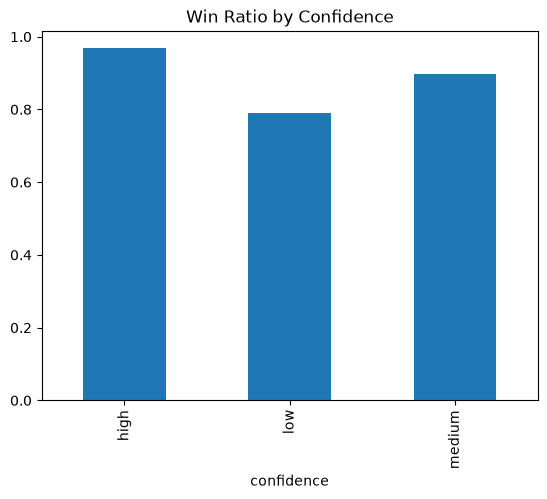

In [6]:
df['selected_ad_won'] = (
    (~df['is_swapped'] & (df['winner_ad_id'] == df['ad_1_id'])) |
    (df['is_swapped'] & (df['winner_ad_id'] == df['ad_2_id']))
)

win_ratio = df['selected_ad_won'].mean()
print(f"Win ratio of selected ad: {win_ratio:.2%}")

# Win ratio by confidence level
win_ratio_by_conf = df.groupby('confidence')['selected_ad_won'].mean()
display(win_ratio_by_conf)
win_ratio_by_conf.plot(kind='bar', title='Win Ratio by Confidence')
plt.show()


## Selected Ad Win Ratio per Query
Here is the distribution of the win ratio for the selected ad, grouped by each unique query. This helps us understand if the selected ad consistently wins for certain queries and consistently loses for others.

Number of unique queries: 96


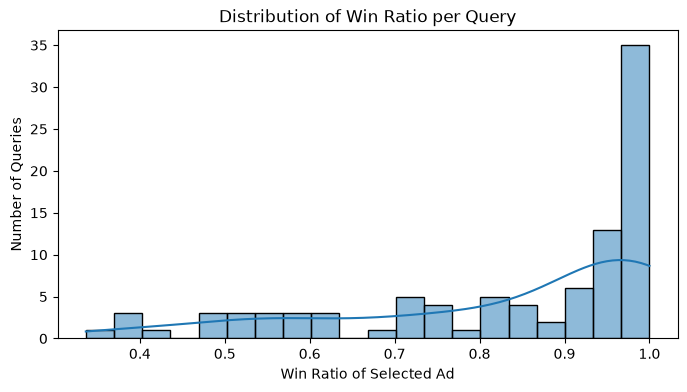

In [7]:
query_win_ratio = df.groupby('query')['selected_ad_won'].mean().sort_values(ascending=False)
print(f"Number of unique queries: {len(query_win_ratio)}")

plt.figure(figsize=(8, 4))
sns.histplot(query_win_ratio, bins=20, kde=True)
plt.title('Distribution of Win Ratio per Query')
plt.xlabel('Win Ratio of Selected Ad')
plt.ylabel('Number of Queries')
plt.show()


In [8]:
print("min:" , query_win_ratio.min())
print("max:" , query_win_ratio.max())
print("median:", query_win_ratio.median())
print("mean:", query_win_ratio.mean())

min: 0.33633633633633636
max: 1.0
median: 0.9316816816816818
mean: 0.8337034951618284


## Cross-Category Evaluation Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cross-category evaluation data
df_cross = pd.read_csv('../data/evaluation/cross_category_preference_scores.csv')

# Note: We won't filter out any queries here unless needed, as this run might still be ongoing.
display(df_cross.head())
print(f"Total evaluated cross-category pairs so far: {len(df_cross):,}")

,query_id,query,ad_1_id,ad_2_id,winner_ad_id,confidence,is_swapped
0,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Computers & Electronics / Networking::16,Arts & Entertainment / nan::1,Arts & Entertainment / nan::1,low,False
1,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Arts & Entertainment / nan::1,Computers & Electronics / Networking::16,Arts & Entertainment / nan::1,low,True
2,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Computers & Electronics / Networking::16,Arts & Entertainment / nan::2,Computers & Electronics / Networking::16,low,False
3,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Arts & Entertainment / nan::2,Computers & Electronics / Networking::16,Arts & Entertainment / nan::2,low,True
4,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Computers & Electronics / Networking::16,Arts & Entertainment / nan::3,Computers & Electronics / Networking::16,low,False


Total evaluated cross-category pairs so far: 1,620,776


In [2]:
# Calculate win ratio for the assigned ad against cross-category ads

def did_assigned_ad_win(row):
    # For cross-category, the assigned ad is always ad_1 when is_swapped=False, and ad_2 when is_swapped=True
    if row['is_swapped'] == False or row['is_swapped'] == 'False':
        return row['winner_ad_id'] == row['ad_1_id']
    else:
        return row['winner_ad_id'] == row['ad_2_id']

# Apply the logic
df_cross['assigned_ad_won'] = df_cross.apply(did_assigned_ad_win, axis=1)

# Overall Win Ratio
overall_win_ratio = df_cross['assigned_ad_won'].mean()
print(f"Overall Assigned Ad Win Ratio (Cross-Category): {overall_win_ratio:.2%}")

# Display breakdown by confidence
print("\nWin Ratio by Confidence Level:")
display(df_cross.groupby('confidence')['assigned_ad_won'].agg(['mean', 'count']).sort_values('count', ascending=False))

Overall Assigned Ad Win Ratio (Cross-Category): 88.56%

Win Ratio by Confidence Level:


,mean,count
confidence,,
low,0.848086,1127846
high,0.971143,437300
medium,0.973773,55630


In [3]:
# Check positional bias for the cross-category evaluation
def did_position_1_win(row):
    return row['winner_ad_id'] == row['ad_1_id']

df_cross['pos_1_won'] = df_cross.apply(did_position_1_win, axis=1)
pos_1_win_rate = df_cross['pos_1_won'].mean()

print(f"Position 1 Win Rate: {pos_1_win_rate:.2%}")
print(f"Position 2 Win Rate: {1 - pos_1_win_rate:.2%}")

Position 1 Win Rate: 52.60%
Position 2 Win Rate: 47.40%


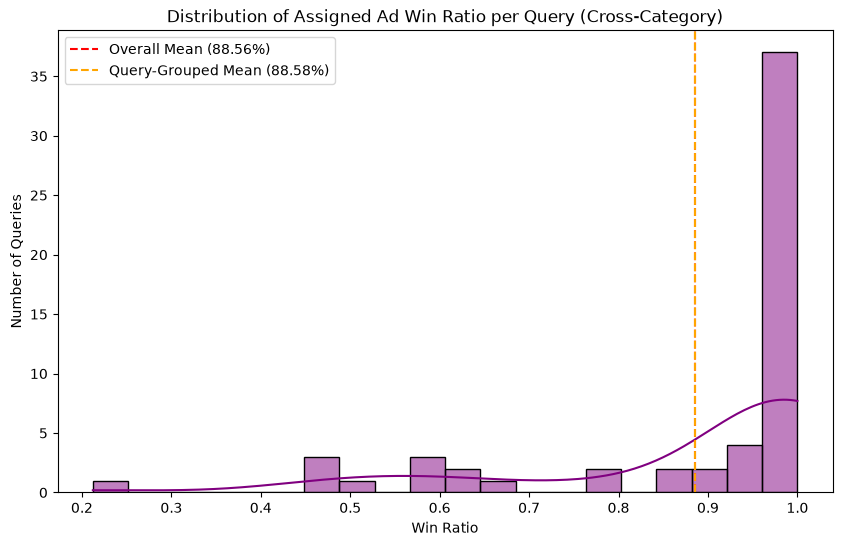

Query-Grouped Mean Win Ratio: 88.58%


In [4]:
# Plotting the Query-Grouped Win Ratio for Cross-Category
query_grouped_cross = df_cross.groupby('query')['assigned_ad_won'].mean()

plt.figure(figsize=(10, 6))
sns.histplot(query_grouped_cross, bins=20, kde=True, color='purple')
plt.title('Distribution of Assigned Ad Win Ratio per Query (Cross-Category)')
plt.xlabel('Win Ratio')
plt.ylabel('Number of Queries')
plt.axvline(overall_win_ratio, color='red', linestyle='--', label=f'Overall Mean ({overall_win_ratio:.2%})')
plt.axvline(query_grouped_cross.mean(), color='orange', linestyle='--', label=f'Query-Grouped Mean ({query_grouped_cross.mean():.2%})')
plt.legend()
plt.show()

print(f"Query-Grouped Mean Win Ratio: {query_grouped_cross.mean():.2%}")

In [5]:
print("min:" , query_grouped_cross.min())
print("max:" , query_grouped_cross.max())
print("median:", query_grouped_cross.median())
print("mean:", query_grouped_cross.mean())

min: 0.21221428571428572
max: 1.0
median: 0.9918214285714286
mean: 0.8858284170999744
